# Dynamic Programming: Policy Iteration vs. Value Iteration

This notebook compares policy iteration and value iteration on the same deterministic GridWorld environment and focuses on their convergence speed.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath(".."))

from envs.grid_world import GridWorld
from algorithms.policy_iteration import policy_iteration
from algorithms.value_iteration import value_iteration
from utils import (
    plot_value_grid,
    plot_policy_arrows,
    plot_value_and_policy,
    plot_convergence_comparison,
)

%matplotlib inline

## Environment Setup

Both algorithms run on the same deterministic GridWorld so their convergence histories are directly comparable.

In [3]:
env = GridWorld(n_rows=12, n_cols=19, seed=82026)

gamma = 0.95
seed = 512

print("Environment Configuration:")
print(f"  - Total Grid States: {len(env.states)}")
print(f"  - Terminal States: {env.terminal_states}")
print(f"  - Non-Terminal States: {len(env.non_terminal_states)}")
print(f"  - Available Actions: {env.ACTIONS}")

Environment Configuration:
  - Total Grid States: 228
  - Terminal States: [(3, 12), (10, 10)]
  - Non-Terminal States: 226
  - Available Actions: ['up', 'down', 'left', 'right']


## Algorithm Runs

We run both algorithms on the same environment, compare their final outputs, and inspect the convergence histories side by side.

Policy Iteration completed in 77518 Bellman backups.
Value Iteration completed in 3842 Bellman backups.
Do optimal values match? True
Do optimal policies match? True


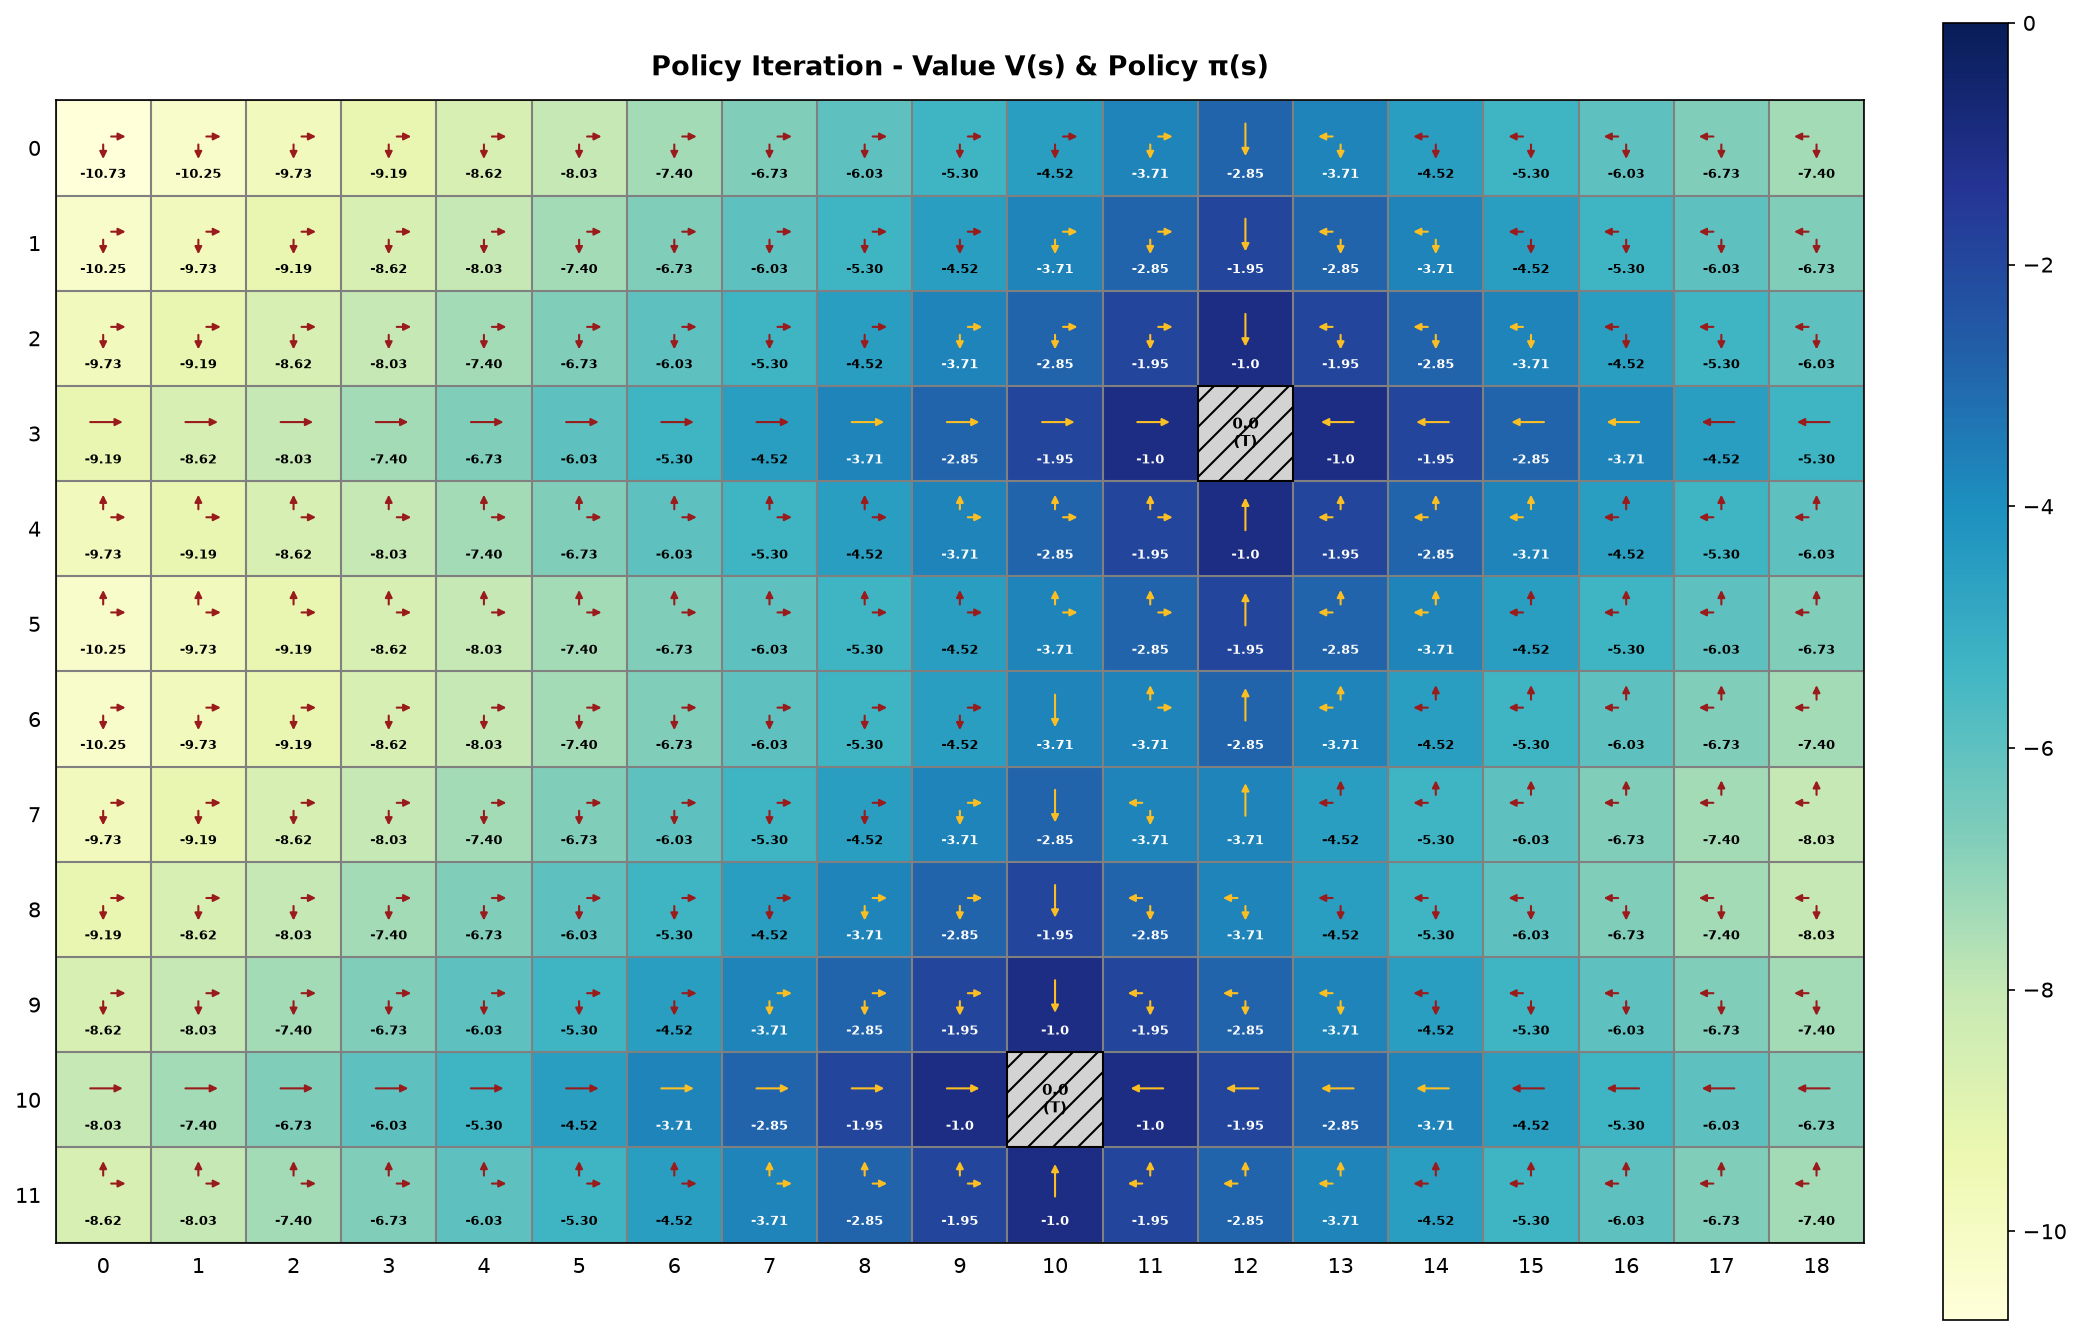

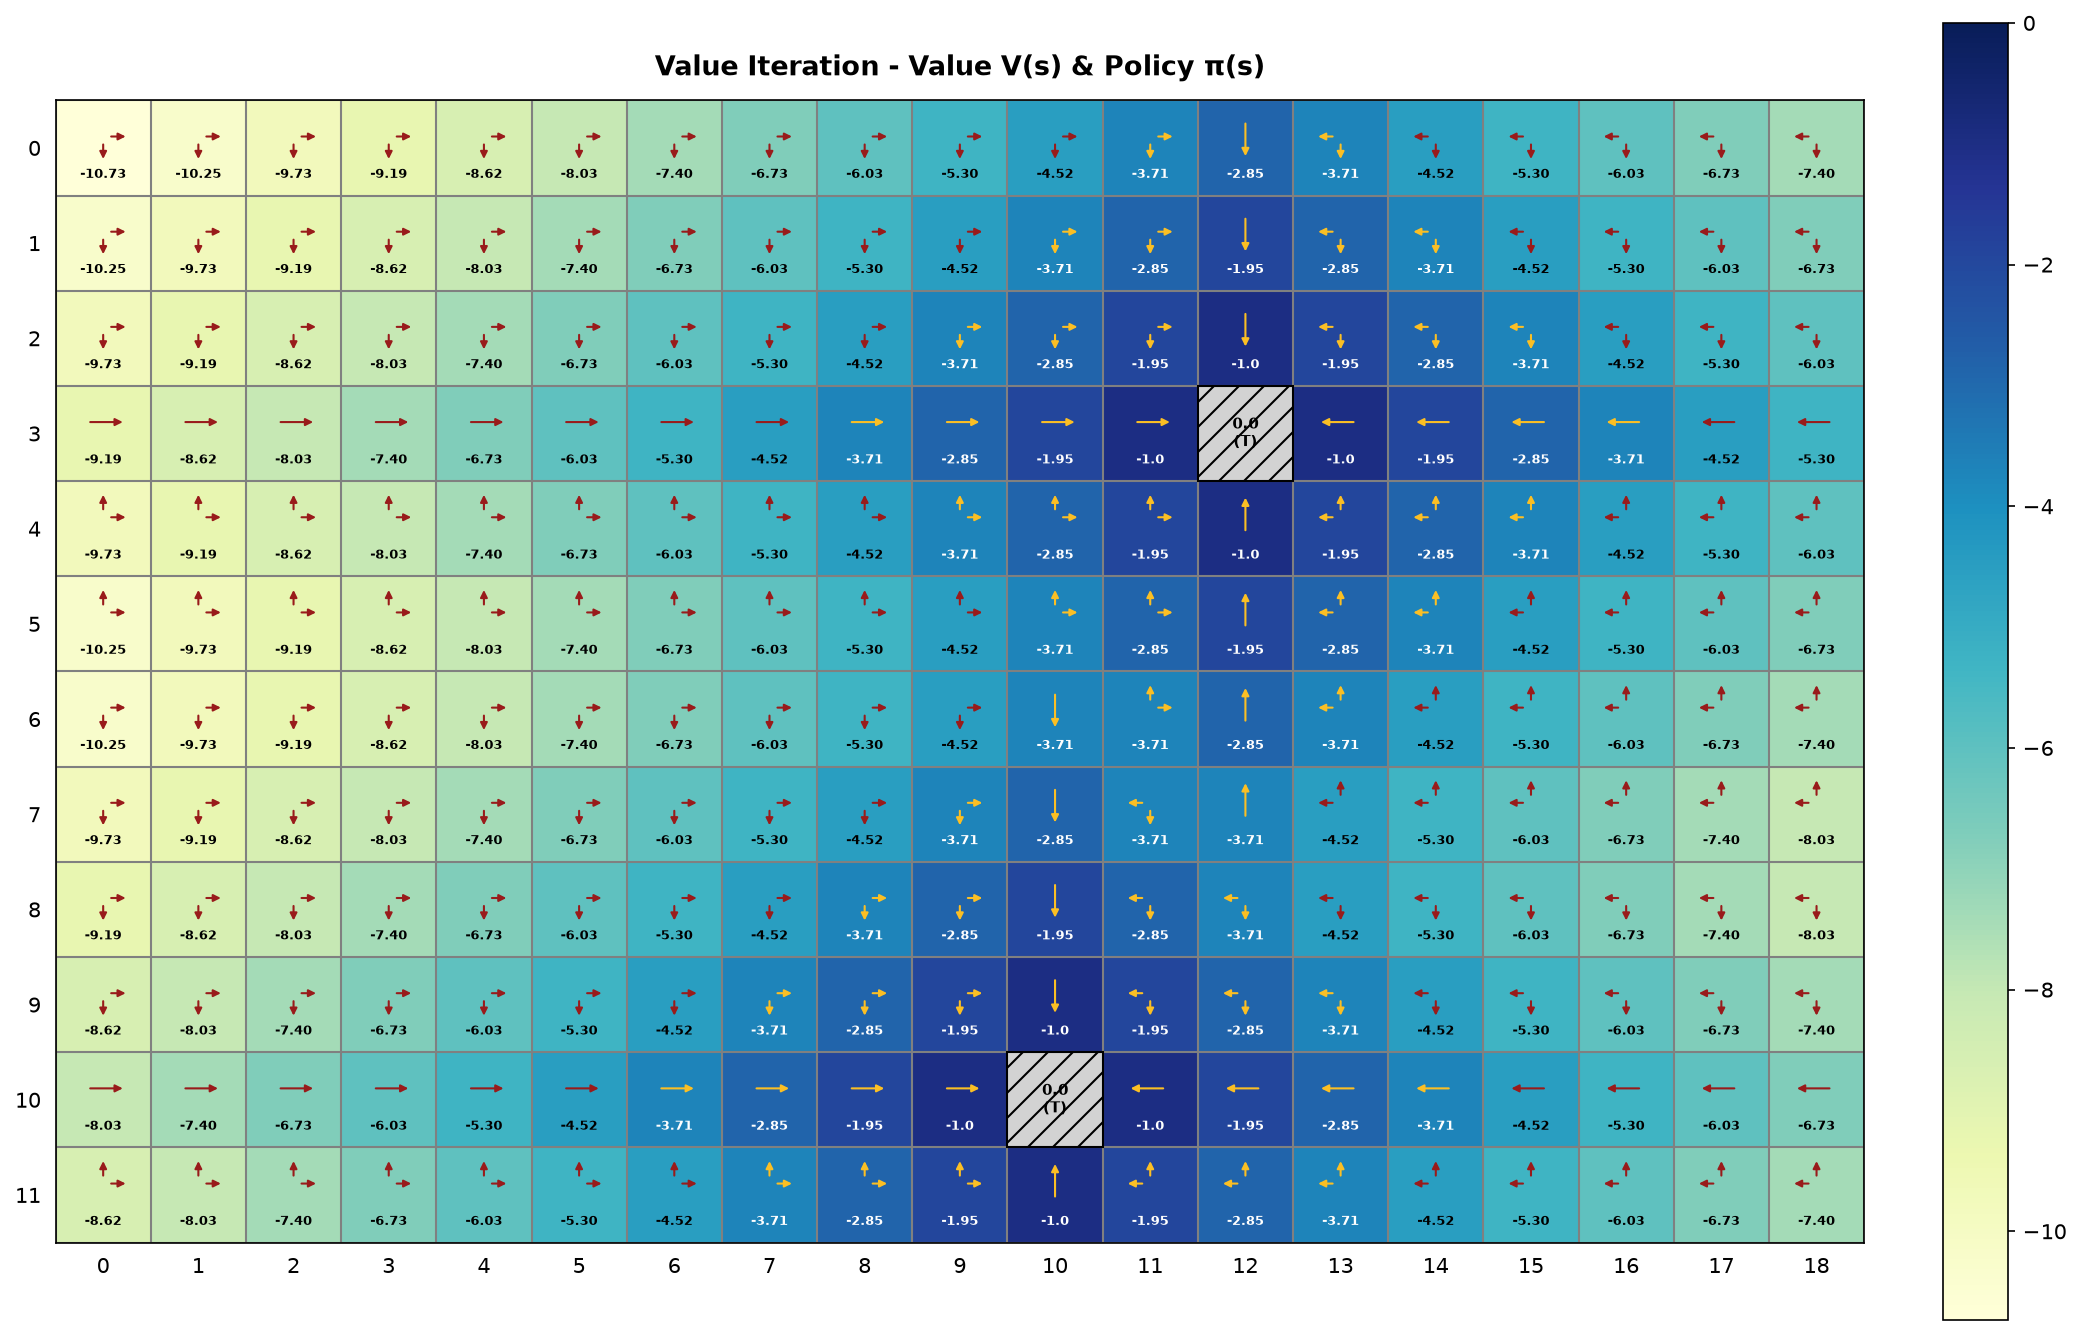

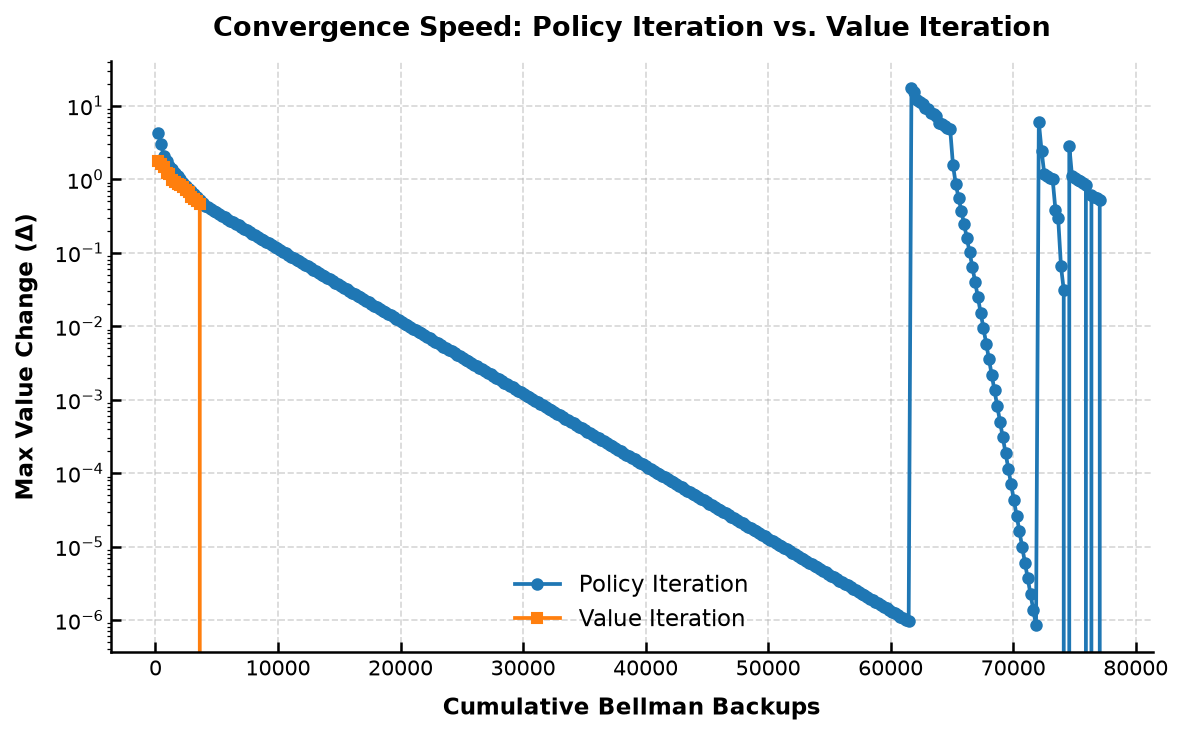

In [4]:
V_pi, pi_pi, history_pi = policy_iteration(
    env=env,
    gamma=gamma,
    seed=seed,
)

V_vi, pi_vi, history_vi = value_iteration(
    env=env,
    gamma=gamma,
    seed=seed,
)

print(f"Policy Iteration completed in {history_pi['backup_count'][-1]} Bellman backups.")
print(f"Value Iteration completed in {history_vi['backup_count'][-1]} Bellman backups.")
print(f"Do optimal values match? {np.allclose(V_pi, V_vi, atol=1e-5)}")
print(f"Do optimal policies match? {pi_pi == pi_vi}")

fig1, ax1 = plot_value_and_policy(
    env,
    V_pi,
    pi_pi,
    title="Policy Iteration - Value V(s) & Policy π(s)",
)
plt.show()

fig2, ax2 = plot_value_and_policy(
    env,
    V_vi,
    pi_vi,
    title="Value Iteration - Value V(s) & Policy π(s)",
)
plt.show()

comparison_history = {
    "Policy Iteration": history_pi,
    "Value Iteration": history_vi,
}

fig3, ax3 = plot_convergence_comparison(
    comparison_history,
    log_scale=True,
    title="Convergence Speed: Policy Iteration vs. Value Iteration",
)
plt.show()

## Remarks

Both algorithms reached the same optimal value function and policy, which confirms that the implementation is consistent. The main difference is efficiency: value iteration converged with far fewer backups, while policy iteration spent most of its work in the first evaluation phase before the policy quickly stabilized. This is exactly what the comparison plot highlights.